# Unsupervised NN

### Model Character
input:
- distribution of d_k (sum = 1)
- |H_k|

output:
- list of b_k
- list of f_dt_k
- list of beta_k

In [194]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [195]:
import numpy as np
import torch


if torch.backends.mps.is_available():
    device = 'mps'
    print("Success: Using Apple Silicon GPU acceleration.")
elif torch.cuda.is_available():
    device = 'cuda'
    print("Success: Using Cuda GPU acceleration.")
else:
    device = 'cpu'
    print("Using CPU.")

Success: Using Cuda GPU acceleration.


## Training

In [196]:
from TrainingUtil import set_seed

set_seed()

In [197]:
from DataUtil import generate_data_loader
import Constants

K = 4
B_total = Constants.total_bandwidth
C_DT_total = Constants.total_compute_speed
beta_max = 3

train_loader, test_loader = generate_data_loader(int(1e5), K, 16e3, comp_speed_range=[Constants.sensor_compression_speed/2, Constants.sensor_compression_speed*2], beta_max=3.5)

In [198]:
from TrainingUtil import unsupervised_loss, train
from torch.optim import Adam, lr_scheduler
from EarlyStopping import EarlyStopping
from NNSolver import Net

model = Net(K, B_total, C_DT_total, beta_max)

optimizer = Adam(model.parameters(), lr=0.01)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
early_stopper = EarlyStopping(patience=5, min_delta=0.1)
loss_fn = unsupervised_loss

train(model, train_loader, test_loader, optimizer, scheduler, early_stopper, loss_fn, device, n_epoch=100)

start training
epoch: 01, avg loss: 1415.6282115684135
epoch: 02, avg loss: 1415.244497205657
epoch: 03, avg loss: 1414.1218983989788
epoch: 04, avg loss: 1430.939029652935
epoch: 05, avg loss: 1417.6400158196877
epoch: 06, avg loss: 1417.1866690629581
epoch: 07, avg loss: 1416.6508852830573
epoch: 08, avg loss: 1416.6222832197827
best epoch: 03, best avg loss: 1414.121898


In [199]:
# state_dict = torch.load('model/checkpoint.pth', map_location=device, weights_only=True)
# model.to(device)
# model.load_state_dict(state_dict)

## Validation

In [200]:
import TrainingUtil as tu
import DataUtil as du
import AnalyzeUtil as au
import ProcessTime as process

length=1000

H = au.to_normal(-40)

H_k = torch.tensor([H, H, H, H])
test_d = torch.tensor([1e3, 1e3, 1e3, 1e3])
test_beta = torch.tensor([1.5, 1.5, 1.5, 1.5])
test_comp_speed = torch.tensor([0.25, 0.75, 1.25, 1.75]) * 200e3
# test_comp_speed = torch.tensor([1, 1, 1, 1]) * 200e3
X_test = torch.cat((test_d, H_k, test_beta, test_comp_speed)).reshape(1, -1).to('cuda')

|   sensor_num |    D |    H(dB) |          b |             f |   beta |   comp_speed | p_k   |   $t_{total}$ |   $t_{comp}$ |   $t_{tr}$ |   $t_{dt}$ |
|-------------:|-----:|---------:|-----------:|--------------:|-------:|-------------:|:------|--------------:|-------------:|-----------:|-----------:|
|            0 | 1000 | -40.0000 | 34563.1523 | 35993980.0000 | 1.5000 |   50000.0000 |       |        4.8959 |       3.1490 |     1.4690 |     0.2778 |
|            1 | 1000 | -40.0000 | 29351.3359 |  4299750.0000 | 1.5000 |  150000.0000 |       |        4.8456 |       1.0497 |     1.4702 |     2.3257 |
|            2 | 1000 | -40.0000 | 19643.5449 |  4785075.0000 | 1.5000 |  250000.0000 |       |        4.1937 |       0.6298 |     1.4741 |     2.0898 |
|            3 | 1000 | -40.0000 | 16441.9570 |  4921198.5000 | 1.5000 |  350000.0000 |       |        3.9582 |       0.4499 |     1.4763 |     2.0320 |

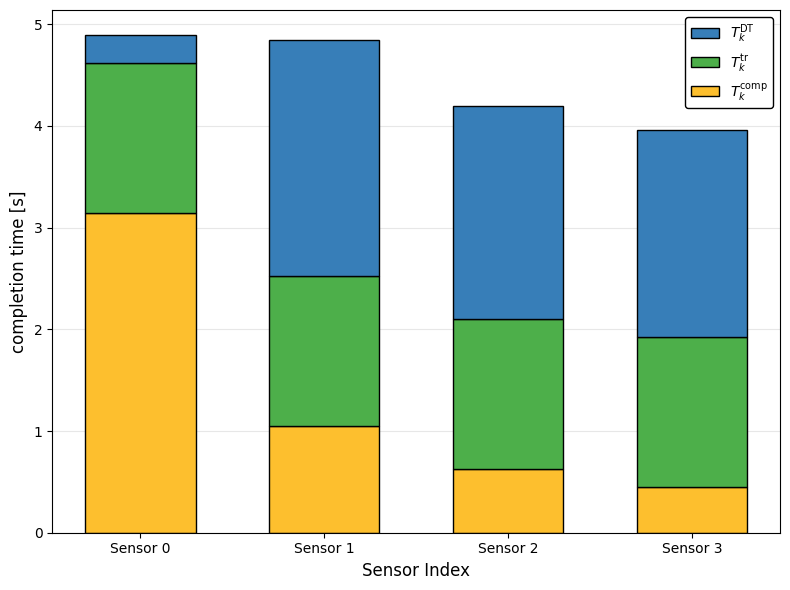

In [201]:
b, f = model(X_test)

b = b.to('cpu')
f = f.to('cpu')
au.plot_result(X_test.to('cpu'), b, f)
au.print_avg(X_test.to('cpu'), b, f)


## Traditional

step=0, loss=5.420576e+00
step=100, loss=4.952534e+00
step=200, loss=4.883755e+00
step=300, loss=4.879513e+00
step=400, loss=4.877915e+00


|   sensor_num |    D |    H(dB) |          b |             f |   beta |   comp_speed | p_k   |   $t_{total}$ |   $t_{comp}$ |   $t_{tr}$ |   $t_{dt}$ |
|-------------:|-----:|---------:|-----------:|--------------:|-------:|-------------:|:------|--------------:|-------------:|-----------:|-----------:|
|            0 | 1000 | -40.0000 | 75880.4766 | 37890976.0000 | 1.5000 |   50000.0000 |       |        4.8783 |       3.1490 |     1.4654 |     0.2639 |
|            1 | 1000 | -40.0000 |  8769.9902 |  4402258.0000 | 1.5000 |  150000.0000 |       |        4.8098 |       1.0497 |     1.4885 |     2.2716 |
|            2 | 1000 | -40.0000 |  7760.1509 |  3896431.5000 | 1.5000 |  250000.0000 |       |        4.6882 |       0.6298 |     1.4919 |     2.5665 |
|            3 | 1000 | -40.0000 |  7589.3828 |  3810334.2500 | 1.5000 |  350000.0000 |       |        4.5669 |       0.4499 |     1.4926 |     2.6244 |

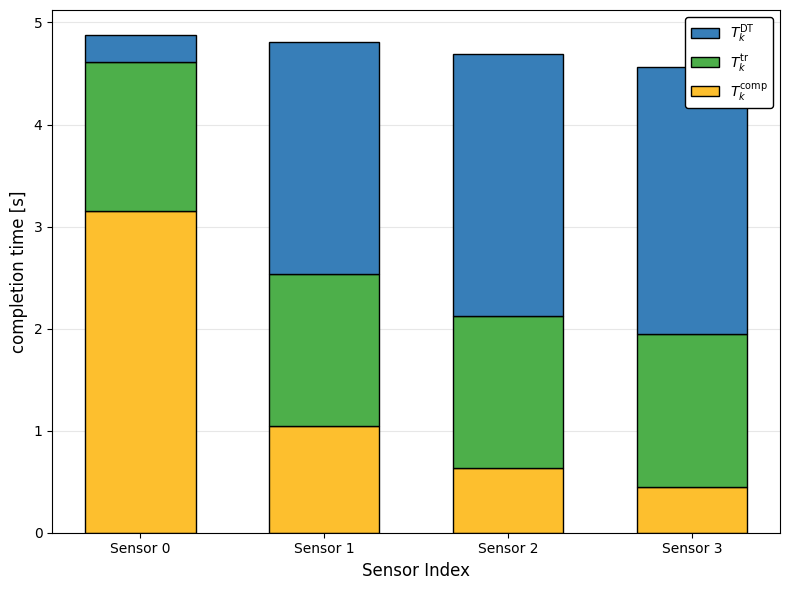

In [202]:
from TraditionalSolver import TraditionalLeaderOptimizer

leader_solver = TraditionalLeaderOptimizer(
    K=K,
    min_share=1e-4,
    dtype=torch.float32,
    device="cuda",
)

result = leader_solver.solve(
    X_test,
    steps=500,
    lr=1e-2,
    tau=None,
    optimizer_type="adam",
    verbose=True,
)

au.plot_result(X_test.to('cpu'), result["b"].to('cpu'), result['f'].to('cpu'))
au.print_avg(X_test.to('cpu'), result["b"].to('cpu'), result['f'].to('cpu'))


c:\Users\YCMic\Documents\Bachelor-Thesis\src\Algorithm.py:99: RuntimeWarning: divide by zero encountered in log
  beta_values = (1 / epsilon) * np.log(
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Algorithm.py:129: RuntimeWarning: divide by zero encountered in divide
  g2 = 1 / mu - beta
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Algorithm.py:131: RuntimeWarning: invalid value encountered in multiply
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2


|         D |   H_mag(dB) |      p |   comp_speed |          b |             f |   beta |   lambda_1 |   lambda_2 |   $t_{total}$ |   $t_{comp}$ |   $t_{tr}$ |   $t_{dt}$ |
|----------:|------------:|-------:|-------------:|-----------:|--------------:|-------:|-----------:|-----------:|--------------:|-------------:|-----------:|-----------:|
| 1000.0000 |    -40.7619 | 0.0316 |  200000.0000 |  2235.4592 |  1404271.7500 | 1.3546 |     0.0000 |     2.4884 |       14.5587 |       0.5454 |     3.8741 |    10.1391 |
| 3000.0000 |    -40.7498 | 0.0316 |  200000.0000 | 12534.6035 |  7412127.0000 | 1.3470 |     0.0000 |     7.1796 |       17.9129 |       1.5546 |    10.7472 |     5.6111 |
| 5000.0000 |    -40.7594 | 0.0316 |  200000.0000 | 34995.4414 | 15289474.0000 | 1.3446 |     0.0000 |    11.8154 |       24.6741 |       2.5479 |    17.7064 |     4.4199 |
| 7000.0000 |    -40.7569 | 0.0316 |  200000.0000 | 50234.4609 | 25894126.0000 | 1.3439 |     0.0000 |    15.6569 |       29.2312 |       3.3144 |    22.5451 |     3.3717 |

|    |   iter |   objective |          diff |   max_time_mean |   max_time_max |
|---:|-------:|------------:|--------------:|----------------:|---------------:|
|  0 |      0 |     40.1401 | inf           |         40.1401 |        1212.97 |
|  1 |      1 |     38.5929 |   1.54718     |         38.5929 |        1202.77 |
|  2 |      2 |     38.5742 |   0.0186768   |         38.5742 |        1191.55 |
|  3 |      3 |     38.5718 |   0.00246429  |         38.5718 |        1193.98 |
|  4 |      4 |     38.5684 |   0.00333023  |         38.5684 |        1189.04 |
|  5 |      5 |     38.561  |   0.00746918  |         38.561  |        1186.17 |
|  6 |      6 |     38.5606 |   0.00030899  |         38.5606 |        1185.08 |
|  7 |      7 |     38.5579 |   0.00278091  |         38.5579 |        1184.35 |
|  8 |      8 |     38.5569 |   0.000923157 |         38.5569 |        1183.74 |
|  9 |      9 |     38.5596 |   0.00269318  |         38.5596 |        1183.17 |
| 10 |     10 |     38.5607 |   0.00108719  |         38.5607 |        1182.71 |
| 11 |     11 |     38.5606 |   0.000175476 |         38.5606 |        1182.18 |
| 12 |     12 |     38.5605 |   6.48499e-05 |         38.5605 |        1182.05 |
| 13 |     13 |     38.56   |   0.00044632  |         38.56   |        1181.95 |
| 14 |     14 |     38.56   |   1.52588e-05 |         38.56   |        1181.89 |
| 15 |     15 |     38.56   |   6.86646e-05 |         38.56   |        1181.83 |
| 16 |     16 |     38.5599 |   1.14441e-05 |         38.5599 |        1181.78 |
| 17 |     17 |     38.5599 |   1.52588e-05 |         38.5599 |        1181.76 |
| 18 |     18 |     38.5599 |   3.8147e-06  |         38.5599 |        1181.73 |
| 19 |     19 |     38.5599 |   3.8147e-06  |         38.5599 |        1181.71 |
| 20 |     20 |     38.5599 |   7.62939e-06 |         38.5599 |        1181.69 |
| 21 |     21 |     38.5599 |   0           |         38.5599 |        1181.68 |

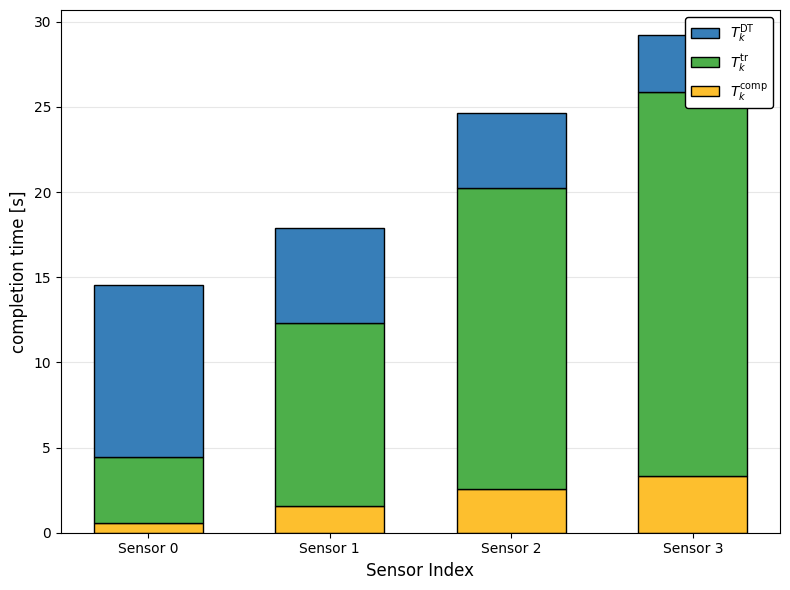

In [203]:
from Algorithm import Algorithm
from CVXLeaderModel import CVXLeaderModel
from IPython.display import display, Markdown

D = (np.array([0.25, 0.75, 1.25, 1.75]) * 4e3 ).reshape(1, -1)
D = np.repeat(D, 1000, axis=0)
H = du.generate_channel_gains(1000, 4).numpy()

algo = Algorithm(D, H)

his = algo.optimize(model, max_iters=100)
    
algo.display_df()
algo.plot()
display(Markdown(his.to_markdown()))